# Modelo — XGBoost Tuned

Optimización del XGBoost mediante cross-validation y hyperparameter tuning con `RandomizedSearchCV`. El objetivo es obtener una estimación más robusta del AUC y mejorar la performance sobre el modelo base (AUC: 0.7941).

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

## 1. Carga de datos

In [2]:
X_train = pd.read_parquet('../data/splits/X_train.parquet')
X_test  = pd.read_parquet('../data/splits/X_test.parquet')
y_train = pd.read_parquet('../data/splits/y_train.parquet').squeeze()
y_test  = pd.read_parquet('../data/splits/y_test.parquet').squeeze()

print('Train:', X_train.shape)
print('Test: ', X_test.shape)

Train: (14807, 13)
Test:  (3702, 13)


In [3]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(xgb_base, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f'AUC por fold: {scores.round(4)}')
print(f'AUC medio:    {scores.mean():.4f} ± {scores.std():.4f}')

AUC por fold: [0.7939 0.7923 0.7824 0.8031 0.7865]
AUC medio:    0.7916 ± 0.0070


In [4]:
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [3, 4, 5, 6, 7],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'subsample':         [0.6, 0.8, 1.0],
    'colsample_bytree':  [0.6, 0.8, 1.0],
    'min_child_weight':  [1, 3, 5]
}

search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, eval_metric='auc'),
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f'Mejor AUC CV: {search.best_score_:.4f}')
print(f'Mejores parámetros: {search.best_params_}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejor AUC CV: 0.7972
Mejores parámetros: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}


In [5]:
best_model = search.best_estimator_
best_model.fit(X_train, y_train) 

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f'ROC-AUC test: {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Retuvo', 'Churnó']))

ROC-AUC test: 0.7948

              precision    recall  f1-score   support

      Retuvo       0.68      0.69      0.69      1632
      Churnó       0.76      0.75      0.75      2070

    accuracy                           0.72      3702
   macro avg       0.72      0.72      0.72      3702
weighted avg       0.72      0.72      0.72      3702



In [6]:
import shap

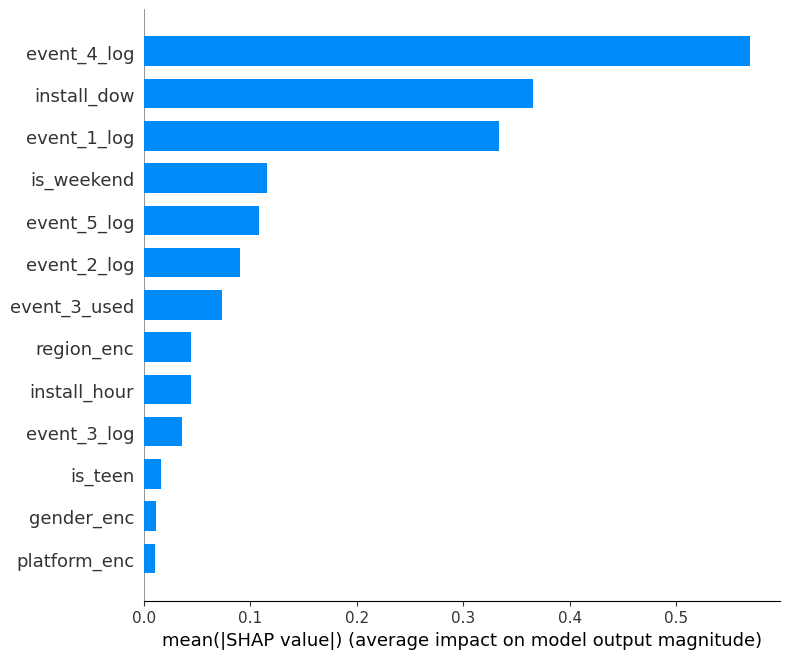

In [7]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar', show=True)

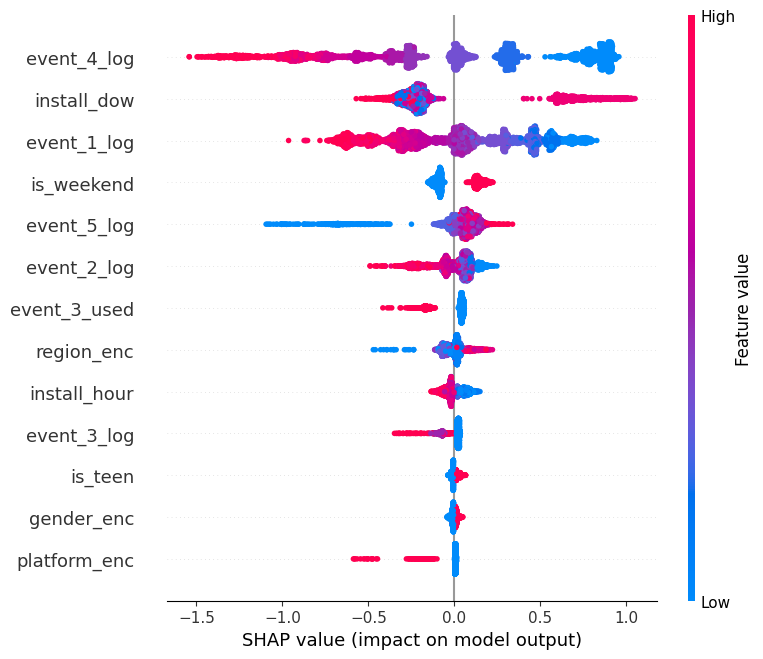

In [8]:
shap.summary_plot(shap_values, X_test, show=True)

**Interpretación SHAP:**

El dot plot muestra el impacto de cada feature en cada predicción individual. Rojo = valor alto de la feature, azul = valor bajo. SHAP hacia la derecha aumenta la probabilidad de churn, hacia la izquierda la reduce.

- **`event_4_log`**: valores altos (rojo) reducen fuertemente el churn — es la feature con mayor impacto individual en el modelo.
- **`install_dow`**: valores altos (fin de semana) aumentan el churn, consistente con el EDA donde el sábado mostraba 73% de churn.
- **`event_1_log`**: patrón claro y simétrico — más actividad en D0 reduce el churn.
- **`event_5_log`**: valores bajos tienen SHAP muy negativo, probablemente por correlación con otras features de eventos.
- **`platform_enc`**: iOS (valor alto) empuja a la izquierda → reduce el churn, aunque con poco impacto global.
- **`gender_enc`, `is_teen`, `platform_enc`**: impacto marginal — confirma que las features demográficas aportan poco al modelo.

---
## Conclusiones finales

**Modelo seleccionado:** XGBoost con hyperparameter tuning.

| Modelo | AUC CV | AUC Test |
|---|---|---|
| Logistic Regression | — | 0.7749 |
| Random Forest | — | 0.7731 |
| XGBoost base | 0.7916 | 0.7941 |
| **XGBoost tuned** | **0.7972** | **0.7948** |

**El modelo final tiene:**
- AUC test de **0.7948** — el mejor de los cuatro modelos evaluados
- AUC CV de **0.7972 ± 0.007** — estimación robusta con 5-fold stratified CV, sin overfitting
- Accuracy del 72% con F1 balanceado entre ambas clases

**Features más importantes (SHAP):** `event_4_log`, `install_dow`, `event_1_log` — el comportamiento del usuario en D0 y el momento de instalación son los predictores más fuertes de churn.

**Parámetros óptimos:** `max_depth=3`, `learning_rate=0.05`, `n_estimators=200`, `subsample=0.8`, `colsample_bytree=0.6` — árboles más simples que el default, lo que sugiere que el dataset no requiere modelos muy complejos para generalizar bien.

In [9]:
import joblib
joblib.dump(best_model, '../data/processed/xgboost_tuned.pkl')
print('Modelo guardado en data/processed/xgboost_tuned.pkl')

Modelo guardado en data/processed/xgboost_tuned.pkl
